29-06-2026

In [3]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv('C:\\Users\\WELCOME\\OneDrive\\Desktop\\ML\\Student_Performance.csv')
X = df.drop(columns='Performance Index')
y= df['Performance Index']

In [5]:
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

In [6]:
num_cols

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced'],
      dtype='object')

In [7]:
obj_cols

Index(['Extracurricular Activities'], dtype='object')

### To check weather the outliers are present or not

<Axes: >

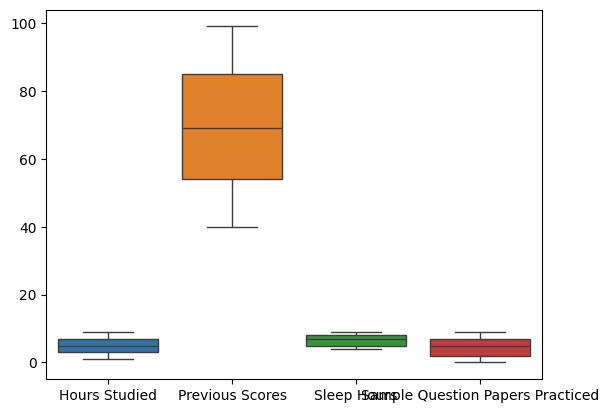

In [8]:
sns.boxplot(X[num_cols])

In [9]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [10]:
scaling = MinMaxScaler()
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [11]:
xtrain[num_cols]

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,0.6,0.555556
1561,0.125,0.135593,0.6,0.666667
1670,0.125,0.694915,0.6,0.222222
6087,0.125,0.101695,0.4,0.111111
6669,0.875,0.118644,1.0,0.000000
...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667
5191,0.375,0.474576,1.0,0.333333
5390,1.000,0.135593,0.6,0.666667
860,0.000,0.118644,1.0,0.000000


In [12]:
df[num_cols].corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
Hours Studied,1.000000,-0.012390,0.001245,0.017463
Previous Scores,-0.012390,1.000000,0.005944,0.007888
Sleep Hours,0.001245,0.005944,1.000000,0.003990
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000


In [13]:
# Based on the unique values chose the encoding technique
xtrain[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

In [14]:
#create obj for label encoder and onehot encoder
# label_encoder=LabelEncoder()
# xtrain['Extracurricular Activities']=label_encoder.fit_transform(xtrain['Extracurricular Activities'])
# xtrain

# To run below command comment label_encoder cell

In [15]:
#create obj for onehot encoder 
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
values=encoder.fit_transform(xtrain[obj_cols])
cols=encoder.get_feature_names_out()
xtrain.drop(columns=['Extracurricular Activities'],inplace=True)

xtrain[cols] = values

In [16]:
cols

array(['Extracurricular Activities_No', 'Extracurricular Activities_Yes'],
      dtype=object)

In [17]:
values

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [18]:
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [19]:
xtest[num_cols]=scaling.transform(xtest[num_cols])
xtest_values = encoder.transform(xtest[obj_cols])
xtest[cols]=xtest_values
xtest.drop(columns=['Extracurricular Activities'],inplace=True)
xtest

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
6252,0.500,0.491525,0.8,0.222222,1.0,0.0
4684,0.125,0.101695,0.0,0.888889,0.0,1.0
1731,0.750,0.271186,0.6,0.555556,0.0,1.0
4742,0.625,0.033898,0.8,0.555556,0.0,1.0
4521,0.750,0.220339,0.0,0.666667,1.0,0.0
...,...,...,...,...,...,...
6412,0.125,0.508475,0.6,0.333333,1.0,0.0
8285,0.375,0.661017,1.0,0.333333,1.0,0.0
7853,0.125,0.000000,0.6,0.222222,0.0,1.0
1095,0.250,0.728814,0.6,0.555556,1.0,0.0


In [20]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
#Evaluation
model.score(xtrain,ytrain)


0.9886898790682355

In [22]:
model.score(xtest,ytest)

0.9889832909573145